In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')

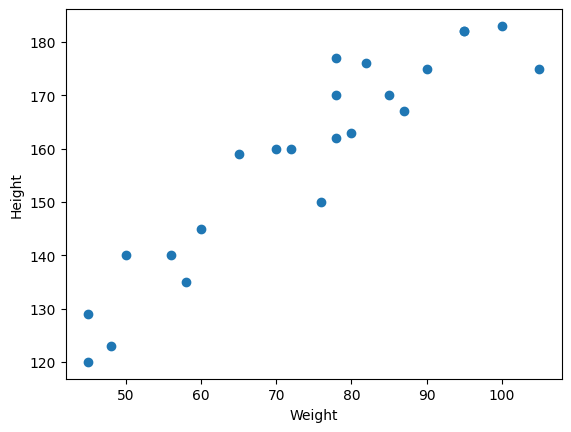

In [5]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [12]:
##Divide independent and dependent features
X=df[['Weight']]
y=df[['Height']]

In [13]:
##Splitting the model into training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Performing Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [16]:
##Model selection and training
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)



LinearRegression()

In [21]:
regression.coef_,regression.intercept_

(array([[17.03440872]]), array([157.5]))

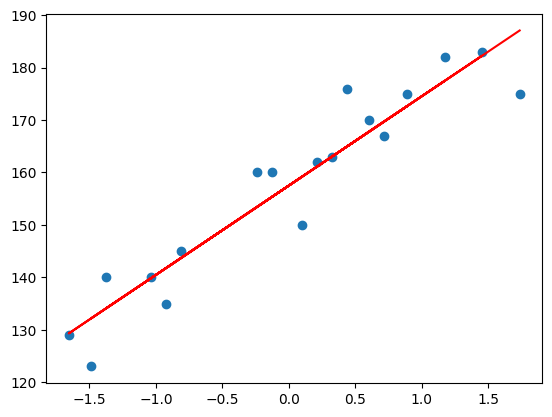

In [22]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),'r')

In [24]:
Y_pred_test = regression.predict(X_test)

In [27]:
Y_pred_test,y_test

(array([[163.44962265],
        [163.44962265],
        [129.59832137],
        [180.88817179],
        [150.11426154]]),
     Height
 15     177
 9      170
 0      120
 8      182
 17     159)

In [28]:
#Performance Metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error

mse = mean_squared_error(y_test,Y_pred_test)
mae = mean_absolute_error(y_test,Y_pred_test)
rmse = root_mean_squared_error(y_test,Y_pred_test)

print(mse,mae,rmse)

79.76809057832979 7.9393285483063725 8.931298370244372


In [ ]:
from sklearn.metrics import r2_score, adj

score = r2_score(y_test,Y_pred_test)
score_adjusted = 1 - score
print(score)
print(score_adjusted)

0.8379487839705635
0.1620512160294365


In [31]:
n = len(y_test)
k = X_test.shape[1]

adjusted_r2 = 1 - ((1-score)*(n-1)/(n-k-1))
print(adjusted_r2)

0.7839317119607513
